In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import anndata
import scipy

import os

import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import warnings
warnings.simplefilter("ignore", UserWarning)

In [2]:
import session_info
session_info.show()

In [3]:
sc.settings.set_figure_params(dpi=120)

In [4]:
import importlib.util
import sys
spec = importlib.util.spec_from_file_location("module.name", "/rfs/project/rfs-iCNyzSAaucw/kk837/function/python/utils.py")
utils = importlib.util.module_from_spec(spec)
sys.modules["module.name"] = utils
spec.loader.exec_module(utils)

# Variables

In [5]:
data_object_dir = '/rfs/project/rfs-iCNyzSAaucw/kk837/data_objects/Foetal/VisiumHD/Revision_Oct2025'
latent_space_condition = 'n-layers-3'
latent_space = f'scVI_latent_{latent_space_condition}'

# Read in adata

In [6]:
%%time
adata = sc.read_h5ad(f'{data_object_dir}/all_b2c_cells_filtered_raw.h5ad')
adata

CPU times: user 467 ms, sys: 2.99 s, total: 3.46 s
Wall time: 46.2 s


AnnData object with n_obs × n_vars = 225097 × 18085
    obs: 'object_id', 'bin_count', 'array_row', 'array_col', 'labels_joint_source', 'in_tissue_manual', 'library', 'donor_section_ID', 'per-frame_donorIDs', 'donor', 'CS', 'est_CS', 'GA', 'PCW', 'section_ID', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'library_donor', 'n_genes'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'PCW_colors', 'donor_colors', 'library_colors', 'neighbors', 'spatial', 'umap'
    obsm: 'X_umap_scVI_n-layers-1', 'X_umap_scVI_n-layers-2', 'X_umap_scVI_n-layers-3', 'X_umap_wo-batch-correction', 'scVI_latent_n-layers-1', 'scVI_latent_n-layers-2', 'scVI_laten

# Clustering

In [7]:
%%time
sc.pp.neighbors(adata, use_rep=latent_space, n_neighbors=15)

/home/kk837/.conda/envs/generic_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


CPU times: user 47.9 s, sys: 523 ms, total: 48.4 s
Wall time: 54.5 s


In [8]:
%%time
leiden_keys=[]
for res in tqdm([0.2,0.3,0.4,0.5,0.8,1.0,1.5,2.0,3.0,4.0]):
    leiden_key = f"leiden_{res}"
    key_added=f"{latent_space}_{leiden_key}"
    sc.tl.leiden(adata,resolution=res,key_added=key_added,n_iterations=2)
    leiden_keys.append(key_added)

  0%|          | 0/10 [00:00<?, ?it/s]<timed exec>:5: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
100%|██████████| 10/10 [11:26<00:00, 68.62s/it]

CPU times: user 11min 19s, sys: 5.38 s, total: 11min 24s
Wall time: 11min 26s


# Save

In [9]:
adata.write(f'{data_object_dir}/all_b2c_cells_filtered_raw.h5ad')

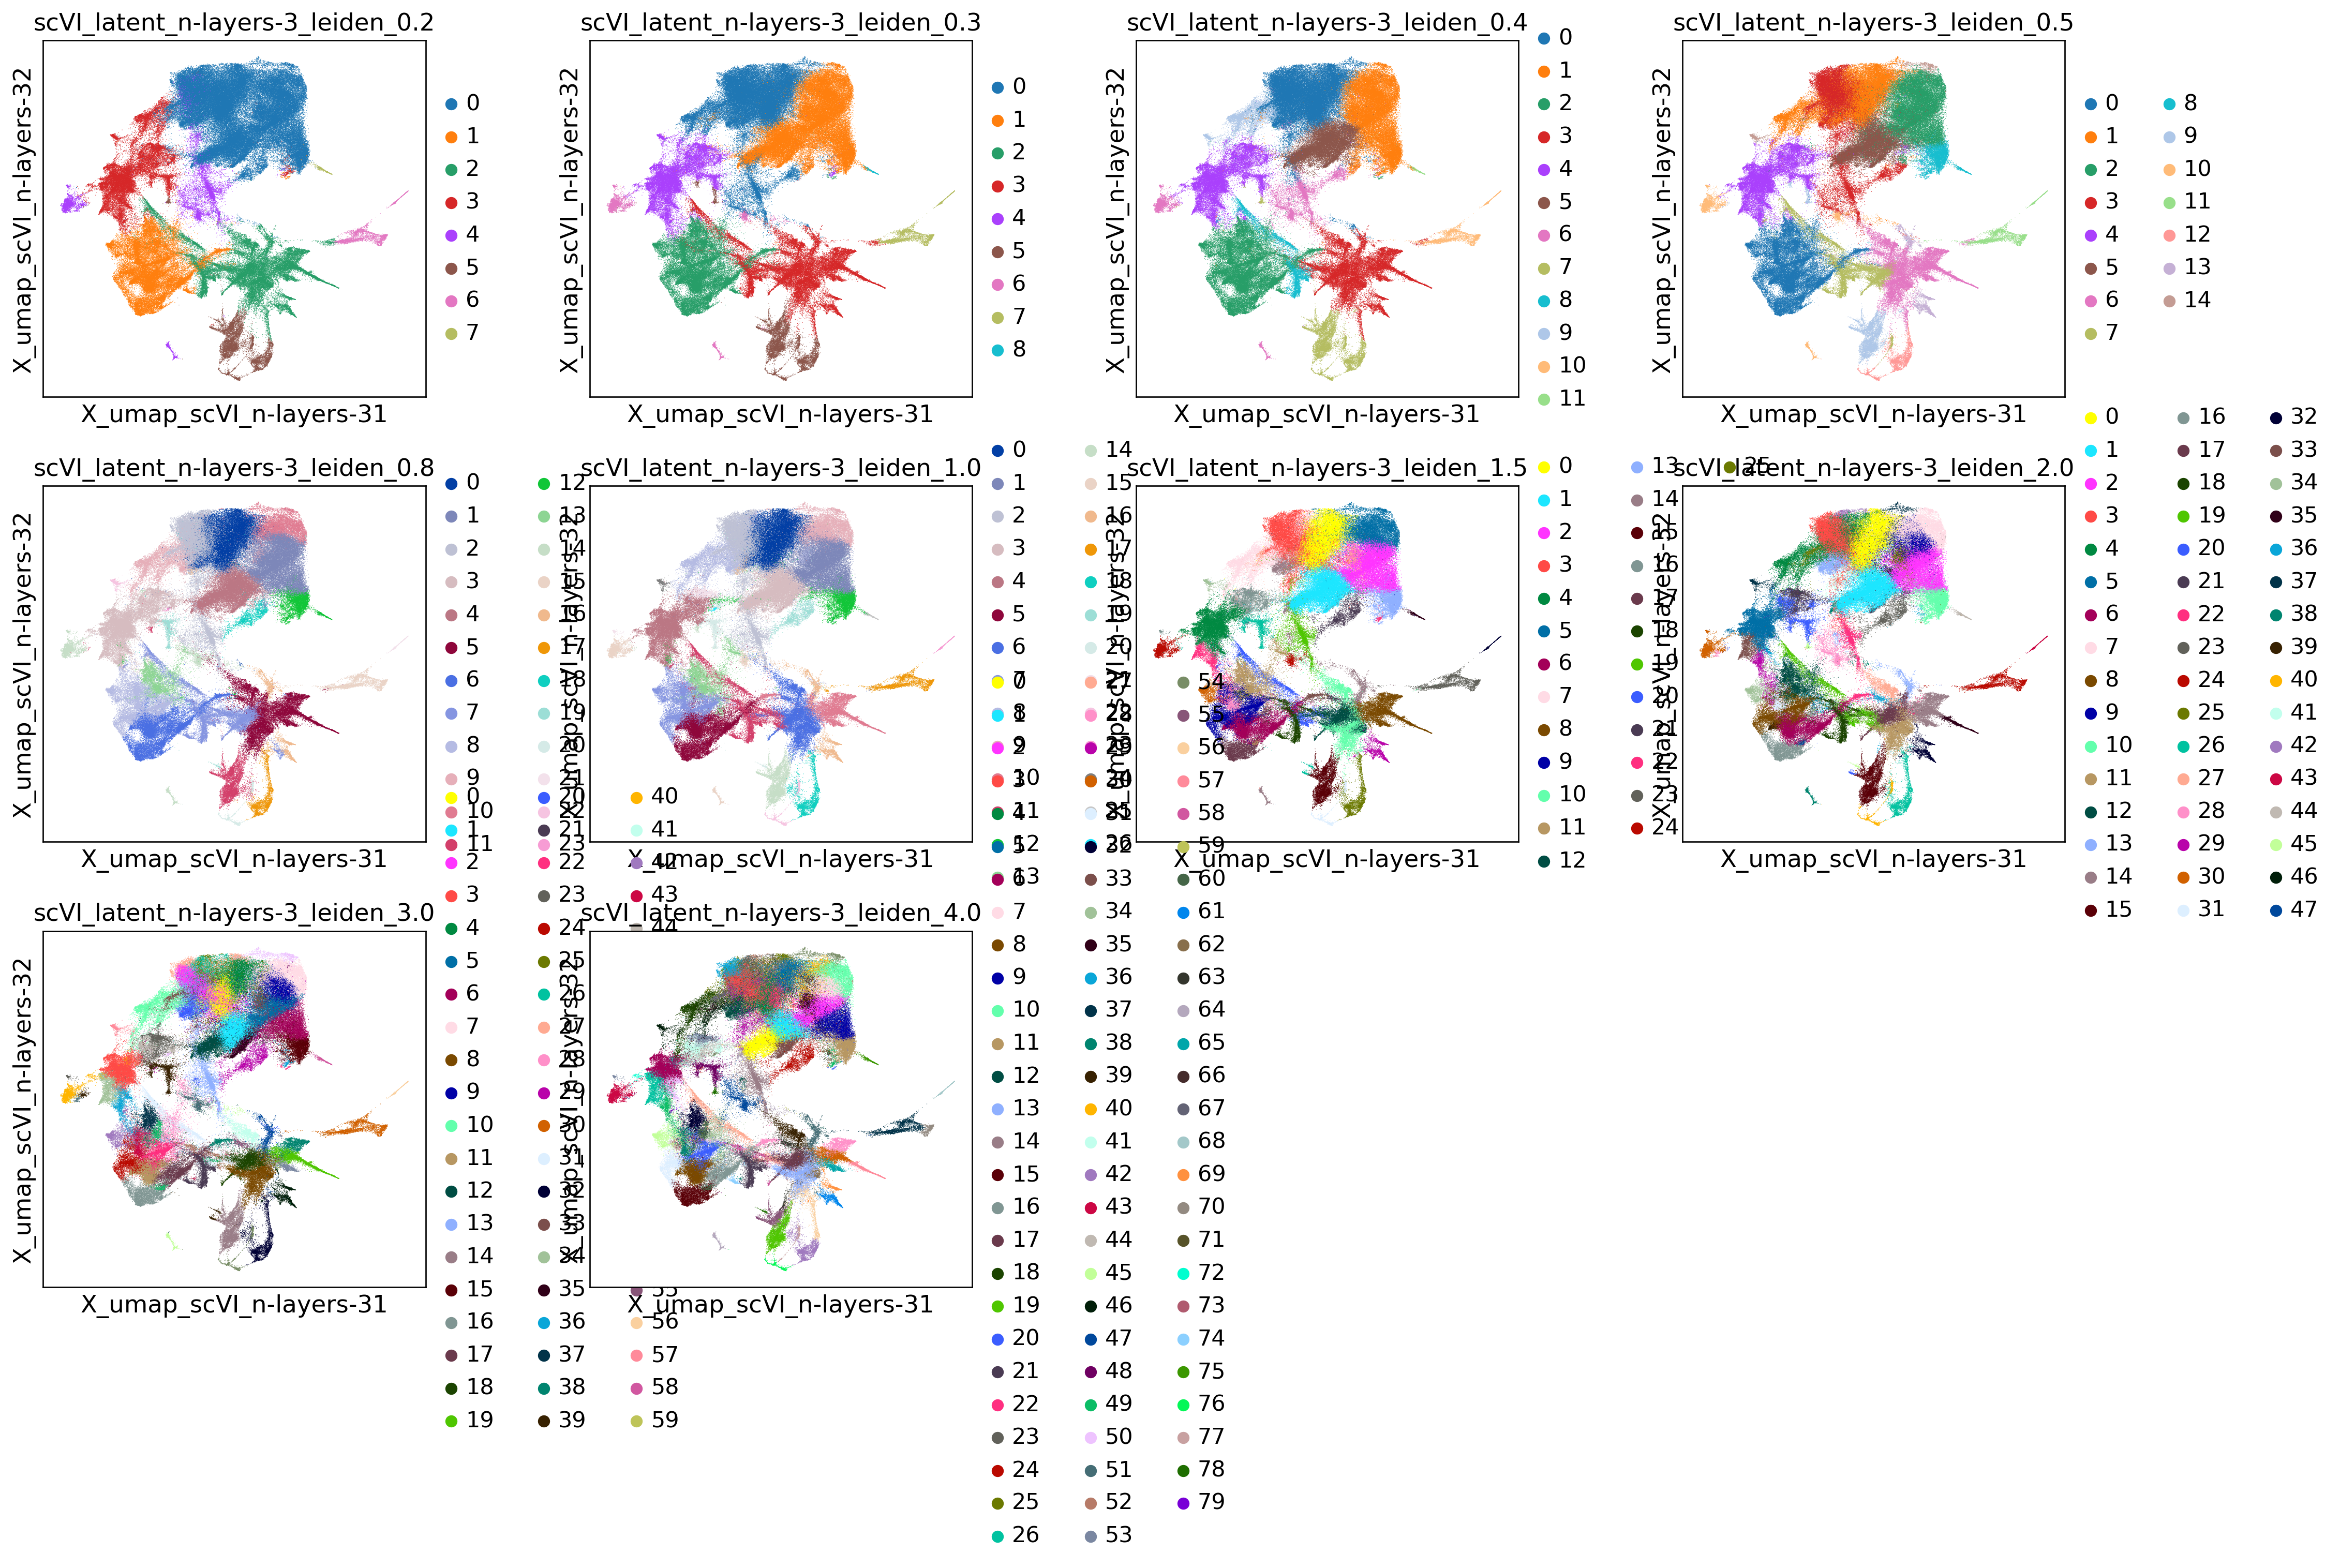

In [10]:
# plot
sc.pl.embedding(adata,basis=f'X_umap_scVI_{latent_space_condition}',
                color=leiden_keys,wspace=0.3,ncols=4)